# 01 · Data Source and Quality

Verify what was supplied, identify structural limitations and define which records are safe for each stage of the analysis.

## Reading guide

This notebook is part of a connected workflow. It states the decision being made, shows the supporting checks and records limitations alongside the result. Source files are never modified in place.

In [1]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_ROOT = Path(os.environ.get("FIFAR_DATA_DIR", PROJECT_ROOT / "data" / "raw" / "FiFAR"))
REPORTS = PROJECT_ROOT / "reports"
IMAGES = PROJECT_ROOT / "images"

sns.set_theme(style="whitegrid")
CORAL = "#F08FA0"
TEAL = "#0E6268"
DARK = "#15262B"

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        "Set FIFAR_DATA_DIR to the extracted official FiFAR directory before running this notebook."
    )

## 1. Source files

FiFAR contains a base bank-account application table, author-generated risk scores, a selected alert population, synthetic analyst decisions and capacity scenarios. These components answer different questions and must not be mixed without checking their keys and row order.

In [2]:
paths = {
    "base": DATA_ROOT / "alert_data" / "Base.csv",
    "scores": DATA_ROOT / "alert_data" / "processed_data" / "BAF_alert_model_score.parquet",
    "alerts": DATA_ROOT / "alert_data" / "processed_data" / "alerts.parquet",
    "expert_predictions": DATA_ROOT / "synthetic_experts" / "expert_predictions.parquet",
    "expert_parameters": DATA_ROOT / "synthetic_experts" / "expert_parameters.parquet",
}
pd.DataFrame({"file": paths.keys(), "exists": [path.exists() for path in paths.values()]})

,file,exists
0,base,True
1,scores,True
2,alerts,True
3,expert_predictions,True
4,expert_parameters,True


## 2. Base schema and target

In [3]:
base = pd.read_csv(paths['base'])
base.shape, base.head(3)

((917174, 32),    fraud_bool  income  ...  device_fraud_count  month
0           1     0.9  ...                 0.0    7.0
1           1     0.9  ...                 0.0    7.0
2           1     0.9  ...                 0.0    7.0

[3 rows x 32 columns])

In [4]:
schema = pd.DataFrame({
    "dtype": base.dtypes.astype(str),
    "missing": base.isna().sum(),
    "unique": base.nunique(dropna=False),
})
schema

,dtype,missing,unique
fraud_bool,int64,0,2
income,float64,0,9
name_email_similarity,float64,0,916232
prev_address_months_count,int64,0,374
current_address_months_count,int64,0,422
customer_age,int64,0,9
days_since_request,float64,0,908181
intended_balcon_amount,float64,0,912963
payment_type,str,0,5
zip_count_4w,int64,0,6303


## 3. Structural completeness

A value of `-1` is a documented source sentinel in several fields. It is not the same as a truncated CSV row and must not be replaced without a field-specific decision.

In [5]:
quality = pd.Series({
    "rows": len(base),
    "columns": base.shape[1],
    "duplicate_rows": base.duplicated().sum(),
    "missing_cells": base.isna().sum().sum(),
    "incomplete_rows": base.isna().any(axis=1).sum(),
    "fraud_cases": base["fraud_bool"].sum(),
    "fraud_rate": base["fraud_bool"].mean(),
})
quality

rows               917174.000000
columns                32.000000
duplicate_rows          0.000000
missing_cells           2.000000
incomplete_rows         1.000000
fraud_cases         11029.000000
fraud_rate              0.012025
dtype: float64

In [6]:
base.loc[base.isna().any(axis=1)]

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,employment_status,credit_risk_score,email_is_free,housing_status,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
917173,0,0.9,0.034934,10,9,20,0.003809,-1.23692,AC,963,6919.207016,5265.658966,4708.098397,0,11,CA,117,0,BC,1,0,-1,0,200.0,0,INTERNET,8.446755,other,1,1,NaN,NaN


**Decision.** Remove only the final structurally incomplete row. Preserve documented sentinels and report their frequency separately.

In [7]:
base_complete = base.loc[~base.isna().any(axis=1)].copy()
base_complete.shape

(917173, 32)

## 4. Monthly completeness

In [8]:
monthly = base_complete.groupby("month")["fraud_bool"].agg(
    applications="size", fraud_cases="sum", fraud_rate="mean"
)
monthly

,applications,fraud_cases,fraud_rate
month,,,
0.0,132440,1500,0.011326
1.0,127620,1198,0.009387
2.0,136979,1198,0.008746
3.0,150936,1392,0.009222
4.0,44864,1452,0.032364
5.0,119323,1411,0.011825
6.0,108168,1450,0.013405
7.0,96843,1428,0.014746


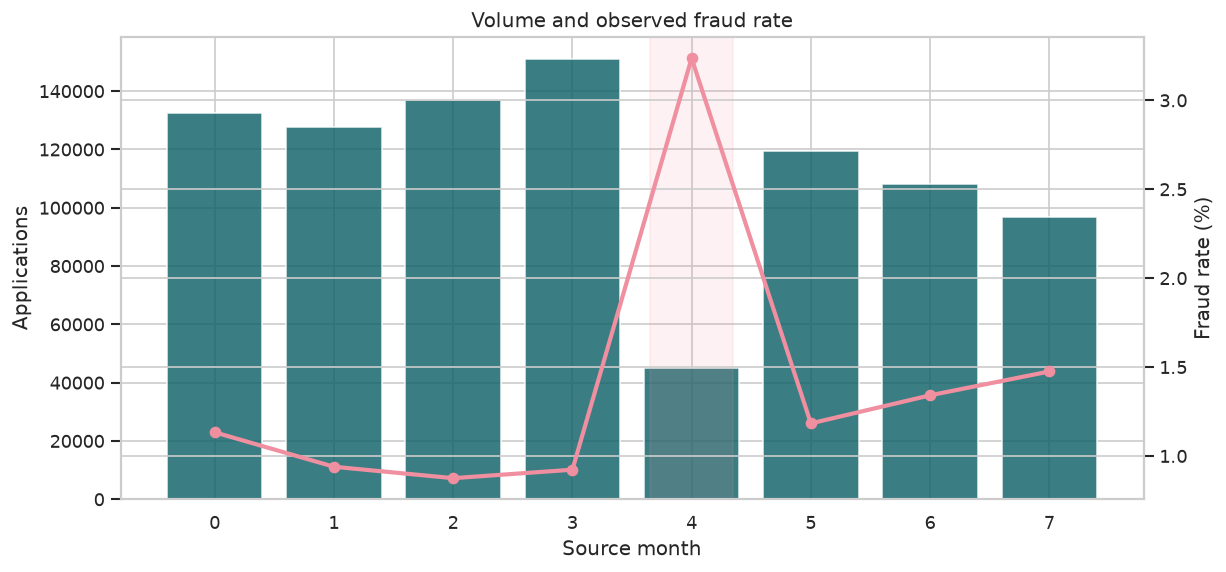

In [9]:
fig, left = plt.subplots(figsize=(11, 5))
right = left.twinx()
left.bar(monthly.index, monthly["applications"], color=TEAL, alpha=.82)
right.plot(monthly.index, monthly["fraud_rate"] * 100, color=CORAL, marker="o", linewidth=2.5)
left.axvspan(3.65, 4.35, color=CORAL, alpha=.12)
left.set(xlabel="Source month", ylabel="Applications", title="Volume and observed fraud rate")
right.set_ylabel("Fraud rate (%)")
plt.show()

Month 4 has substantially lower volume and an implausibly elevated observed fraud rate. Because the file terminates during this month, it is excluded from primary temporal comparisons rather than treated as genuine distribution shift.

## 5. Related table alignment

In [10]:
alerts = pd.read_parquet(paths["alerts"])
scores = pd.read_parquet(paths["scores"])
experts = pd.read_parquet(paths["expert_predictions"])
pd.DataFrame({
    "table": ["base", "author scores", "alerts", "expert predictions"],
    "rows": [len(base), len(scores), len(alerts), len(experts)],
    "columns": [base.shape[1], scores.shape[1], alerts.shape[1], experts.shape[1]],
})

,table,rows,columns
0,base,917174,32
1,author scores,602961,32
2,alerts,30622,33
3,expert predictions,30622,50


The expert-prediction table has the same row count as the alerts table. Their row alignment is used only after confirming this invariant. The scored table is a separate author-provided population and is not joined by row number to the base CSV.

## Conclusion

The archive supports a fraud-ranking study and a downstream alert-review study. The incomplete base month is a material limitation, but it can be isolated without fabricating records or values.